# Stabla odlučivanja i slučajne šume

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

Kako mnoge bibliotečke funkcije zavise od generatora slučajnih brojeva, radi reprodukcibilnosti modela, postavljamo *seed* generatora slučajnih brojeva.

In [2]:
np.random.seed(7)

### Problem koji rešavamo: Klasifikacija karcinoma 

Koristimo skup podataka [Breast Cancer Wisconsin (Diagnostic)](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)).
Skup podataka se sastoji od 33 atributa. Vrednosti atributa su izračunati sa digitalizovanih slika uzoraka tkiva, koje opisuju karakteristike ćelija prikazanih na slici. Vrednost atributa <code>diagnosis</code> sadrži informaciju o tome da li je u pitanju benigni ili maligni tumor.

Viskonsins skup podataka je takođe dostupan u scikit-learn kolekciji podataka kroz paket <code>datasets</code>, a podatke možemo učitati koristeći <code>load_breast_cancer()</code> funkciju ovog paketa.

### 1. Učitavanje i analiza skupa podataka

In [3]:
data = pd.read_csv('data.csv')

In [4]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
data.shape

(569, 33)

In [6]:
data.columns 

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

### 2. Rad sa nedostajućim vrednostima
U skupu postoje nedostajuće vrednosti. Detaljnijom proverom po kolonama, vidimo da se one javljaju samo u koloni <code>Unnamed: 32</code>, kao i da su zapravo sve vrednosti u ovoj koloni *NaN*. Iz tog razloga smatramo da je ovo greška i kolonu izbacujemo iz skupa.

Za početak proveriti da li u skupu postoje nedostajuće vrednosti:

In [7]:
data.isna().any().any() 

True

Zatim proveriti u kojim kolonama se javljaju nedostajuće vrednosti:

In [8]:
data.isna().any() 

id                         False
diagnosis                  False
radius_mean                False
texture_mean               False
perimeter_mean             False
area_mean                  False
smoothness_mean            False
compactness_mean           False
concavity_mean             False
concave points_mean        False
symmetry_mean              False
fractal_dimension_mean     False
radius_se                  False
texture_se                 False
perimeter_se               False
area_se                    False
smoothness_se              False
compactness_se             False
concavity_se               False
concave points_se          False
symmetry_se                False
fractal_dimension_se       False
radius_worst               False
texture_worst              False
perimeter_worst            False
area_worst                 False
smoothness_worst           False
compactness_worst          False
concavity_worst            False
concave points_worst       False
symmetry_w

Proveriti da li su sve vrednosti u koloni <code>Unnamed: 32</code> NaN vrednosti.

In [9]:
data['Unnamed: 32'].isna().all() 

True

Izbaciti kolonu <code>Unnamed: 32</code> iz skupa podataka.

In [10]:
data.drop('Unnamed: 32', axis=1, inplace=True)     #IInacin: data.dropna(axis=1, inplace=True)

Takođe možemo primetiti da kolona <code>id</code> ne sadrži informaciju o karakterisitikama ćelije koju klasifikujemo, pa je i nju potrebno izbaciti iz skupa podataka.

In [11]:
data.drop('id', axis=1, inplace=True)         

Prikazati prvih nekoliko instanci i dimenzije rezultujućeg skupa podataka. 

In [12]:
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [13]:
data.shape

(569, 31)

### 3. Podela skupa na ulazne i ciljne atribute
Informacija o vrsti tumora se nalazi u koloni <code>diagnosis</code> (*ciljni atribut*), dok se ostali atributi koriste za predikciju (*ulazni atributi*).

In [14]:
Y = data['diagnosis']
X = data.drop('diagnosis', axis=1)    #IInacin: data.drop(columns=['diagnosis'])

Izvdojiti nazive ulaznih atributa u posebnu promenljivu (biće nam potrebni kasnije).

In [15]:
feature_names = X.columns
feature_names

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

Proveriti koliko različitih vrednosti uzima ciljni atribut:

In [16]:
Y.unique()

array(['M', 'B'], dtype=object)

Vrednosti u <code>Y</code> (klasa) su <code>M</code> - maligni i <code>B</code> - benigni tumor. Dakle, rešavamo problem _binarne klasifikacije_.

### 4. Provera balansiranosti klasa

Grafički prikazati odnos broja instanci po klasama.

In [17]:
Y.value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

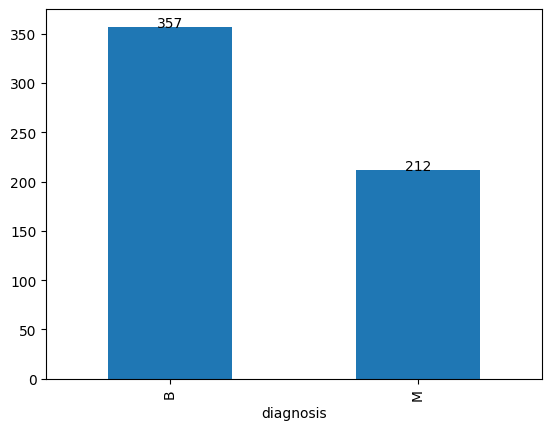

In [18]:
Y.value_counts().plot.bar()

for class_label, class_count in enumerate(Y.value_counts().values):  
    #ispisivanje broja iznad stubića: plt.text(x_position, y_position, text_string)
    plt.text(class_label, class_count, str(class_count), ha='center')

Na osnovu histograma vidimo da se u skupu podataka nalazi 212 instanci malignog i 357 instanci benignog tumora.
Primećujemo blagu nebalansiranost (38%-62%).

_NAPOMENA_: Na narednim časovima ćemo pokazati metode rada sa nebalansiranim klasama.

Tipično, binarna klasifikacija sadrži jednu klasu koja predstavlja _normalno stanje_ i drugu koja predstavlja _abnormalno stanje_. U našem primeru, benigni tumor predstavlja normalno stanje, a maligni abnormalno. 
Klasi koja predstavlja normalno stanje se dodeljuje oznaka **0**, dok se drugoj klasi dodeljuje oznaka **1**.

In [19]:
Y.replace("B", 0, inplace=True)
Y.replace("M", 1, inplace=True)

In [20]:
Y.dtypes

dtype('int64')

*NAPOMENA:* U novijim verzijama će i nakon zamene strinovskih labela klasa numeričkim vrednostima tip kolone Pandas DataFrame-a ostati neizmenjen, tj. <code>object</code>. Tako da je u tom slučaju potrebno nakon zamene vrednosti izmeniti i tip podataka u <code>int64</code>. 

### 5. Analiza ulaznih atributa

Prikazati deskriptivne statistike ulaznih atributa:

In [21]:
X.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Na osnovu deskriptivnih statistika atributa možemo primetiti da se vrednosti nalaze u različitim rasponima.

Pitanja na koja bi trebalo da odogovorimo su:
1. Da li je potrebno izvršiti normalizaciju prilikom korišćenja stabla odlučivanja? (Ne, zašto?)
2. Da li stablo odulučivanja robusno na autlajere? (Da, zašto?)

*DIGRESIJA: Robusnost u statistici se odnosi na stabilno ponašanje metodologije pri malim promenama podataka ili modela. Na primer, mali procenat autlajera može imati veliki uticaj na mnoge statističke tehnike.*

Dodatno pitanje: _Da li su isti odgovori i u situaciji kada bismo stablo odlučivanja koristili za rešavanje problema regresije?_

### 6. Podela skupa podataka na trening i test skup

Završili smo početnu analizu skupa podataka. Sada je potrebno da izvršimo _stratifikovanu_ podelu na **test i trening skup**, u razmeri 1:3.

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, stratify=Y, random_state=41)

In [24]:
X_train.shape

(426, 30)

In [25]:
X_test.shape

(143, 30)

In [26]:
Y_train.shape

(426,)

In [27]:
Y_test.shape

(143,)

Vizuelna provera stratifikovanosti podele skupa podataka:

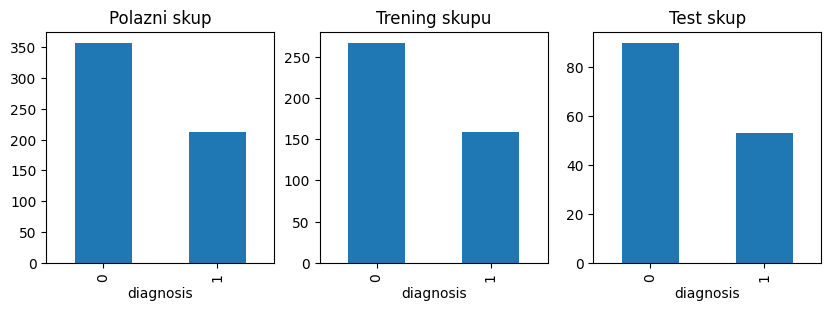

In [28]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 3, 1)
Y.value_counts().plot.bar()
plt.title('Polazni skup')

plt.subplot(1, 3, 2)
Y_train.value_counts().plot.bar()
plt.title('Trening skupu')

plt.subplot(1, 3, 3)
Y_test.value_counts().plot.bar()
plt.title('Test skup')

plt.show()

### 7. Model stabla odlučivanja (default)

Obučiti model stabla odlučivanja sa podrazumevanim vrednostima hiperparametara.

In [29]:
from sklearn.tree import DecisionTreeClassifier

In [30]:
model_dtc = DecisionTreeClassifier()

In [31]:
model_dtc.fit(X_train, Y_train)    #treninranje modela

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Prikazati grafički strukturu dobijenog stabla odlučivanja:

In [32]:
from sklearn.tree import plot_tree

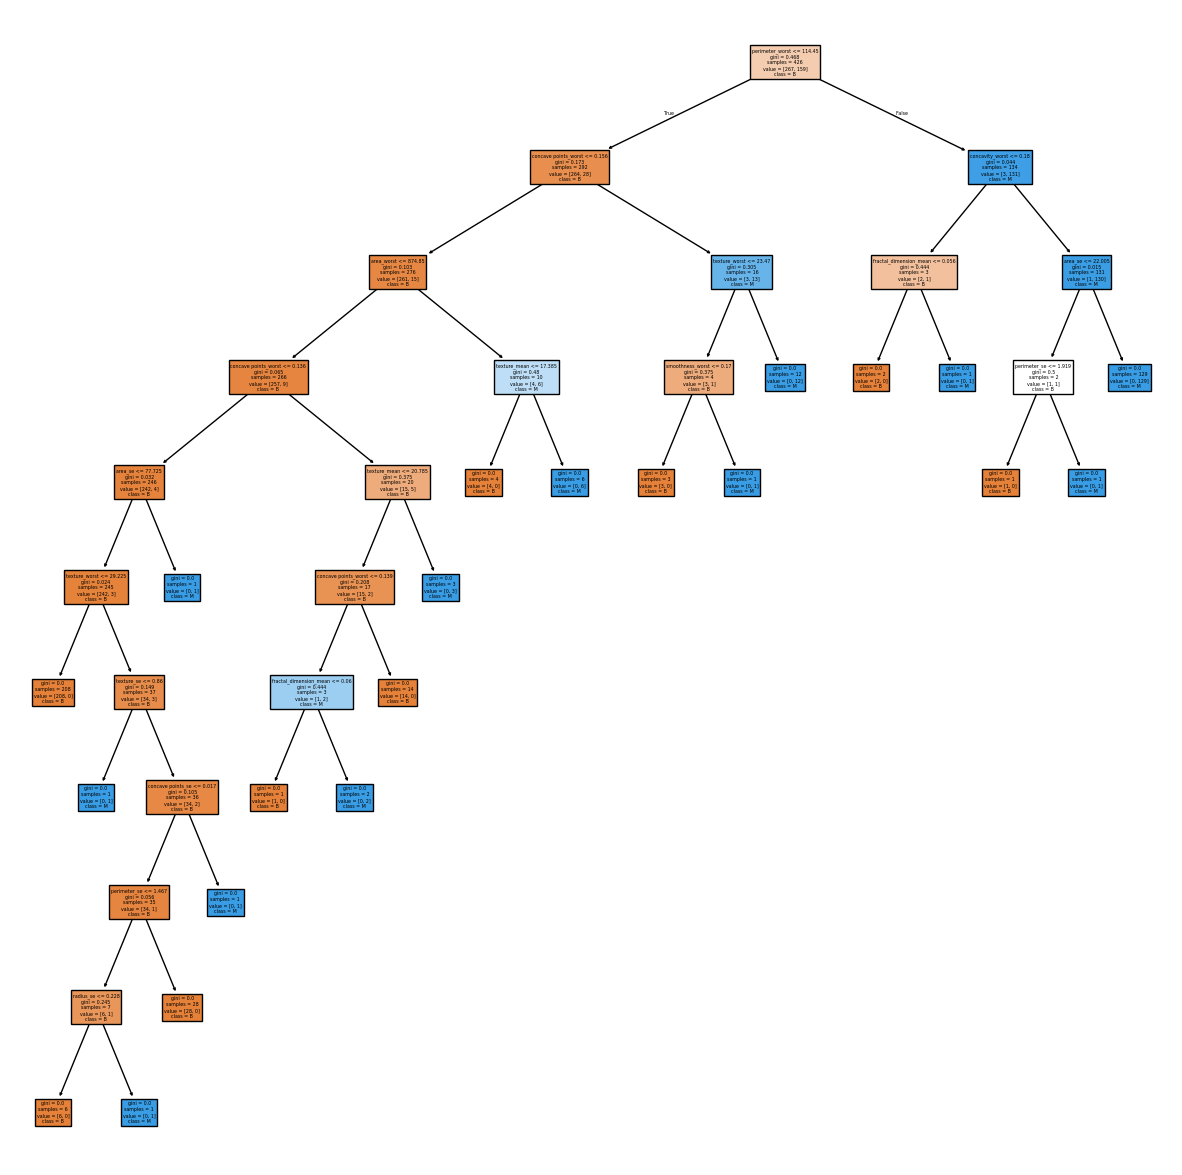

In [33]:
plt.figure(figsize=(15, 15))

_ = plot_tree(model_dtc, feature_names=feature_names, class_names=['B', 'M'], filled=True)

*Primetimo da su čvorovi obojeni različito, prema većinskoj klasi instanci u tom čvoru, dok je čvor koji ima podjednak broj instanci obe klase obojen neutralno. Nijansa obojenosti čvora odražava meru nečistoće podataka u tom čvoru (jača boja - manja nečistoća).*

Ispisati kolika je dubina dobijenog stabla, kao i koliko listova ima.

In [34]:
model_dtc.get_depth()

10

In [35]:
model_dtc.get_n_leaves()

21

Prikazati koji atributi su bili od najvećeg značaja prilikom konstrukcije stabla odlučivanja.

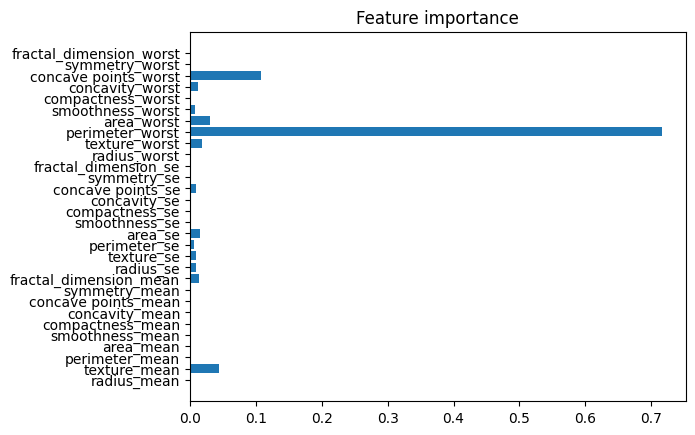

In [36]:
plt.barh(range(len(feature_names)), model_dtc.feature_importances_)
plt.yticks(range(len(feature_names)), feature_names)
plt.title("Feature importance")
plt.show()

Zaključujemo da se prilikom klasifikacije veliki broj atributa ne koristi.

Prikazati klasifikacioni izveštaj i matricu konfuzije na trening skupu.

In [37]:
from sklearn.metrics import classification_report, confusion_matrix

In [38]:
Y_train_predicted = model_dtc.predict(X_train)

In [39]:
confusion_matrix(Y_train, Y_train_predicted)

array([[267,   0],
       [  0, 159]])

In [40]:
print(classification_report(Y_train, Y_train_predicted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       267
           1       1.00      1.00      1.00       159

    accuracy                           1.00       426
   macro avg       1.00      1.00      1.00       426
weighted avg       1.00      1.00      1.00       426



Na osnovu dobijenih rezultata na trening skupu naslućujemo da je došlo do preprilagođavanja. Zato je potrebno proveriti koliko dobro naš model klasifikuje instance koje nije video prilikom obučavanja (test skup).

In [41]:
Y_test_predicted = model_dtc.predict(X_test)

In [42]:
confusion_matrix(Y_test, Y_test_predicted)

array([[85,  5],
       [ 4, 49]])

In [43]:
print(classification_report(Y_test, Y_test_predicted))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95        90
           1       0.91      0.92      0.92        53

    accuracy                           0.94       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.94      0.94      0.94       143



_Pitanje1_: Da li je došlo do preprilagođavanja?

_Pitanje2_: Koju vrstu grešaka u klasifikaciji želimo da minimizujemo - da li nam je bitnije da je *FP* ili *FN* malo?

Evaluirati zatim model u terminima tačnosti klasifikacije, preciznosti, odziva, F1 i AUC mere.

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [45]:
Y_test_predicted = model_dtc.predict(X_test)

In [46]:
accuracy_score(Y_test, Y_test_predicted)

0.9370629370629371

In [47]:
precision_score(Y_test, Y_test_predicted)

0.9074074074074074

In [48]:
recall_score(Y_test, Y_test_predicted)

0.9245283018867925

In [49]:
f1_score(Y_test, Y_test_predicted)

0.9158878504672897

In [50]:
roc_auc_score(Y_test, Y_test_predicted)

0.9344863731656184

*NAPOMENA:* Preciznost, odziv i F1 mera su definisane u odnosu na pozitivnu klasu, odnosno da nisu simetrične u odnosu na izbor neke klase kao pozitivne. Zbog toga u klasifikacionom izveštaju imamo dve vrednosti svake od ovih mera, izračunate za izbor svake od klase kao pozitivne.

Trenutni model, iako ima relativno visoke ocene, pravi veći broj grešaka prvog i drugog reda (*FP* i *FN*), i zato ćemo pokušati da ga unapredimo, promenom hiperparametara.

### 8. Podešavanje hiperparametara modela

U scikit-learn biblioteci, hiperparametri se zadaju kao argumenti konstrukoru.

Želimo da promenimo hiperparametre našeg modela, ali ne znamo koja kombinacija parametara će nam dati najbolji model. Na primer, na osnovu analize prvog modela, zaključili smo da želimo da podeašavamo dva parametra:
<code>max_depth</code> i <code>criterion</code>.

### 8.1. Pogrešan pristup <span title="pickle" style="color: darkgreen ">🚩</span>


Za početak izaberemo jedan od ovih parametara npr. dubinu stabla. Želimo da proverimo za dubine 2, 4, 6 i 8.
Treniramo 4 modela sa različitim dubinama i izaberemo najbolji.

In [51]:
depth_values = [2, 4, 6, 8]
model_accs = []

for depth in depth_values:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, Y_train) 
    model_accs.append(model.score(X_test, Y_test))

Na grafiku prikazati kako se menja tačnost klasifikacije modela za različite dubine stabala.

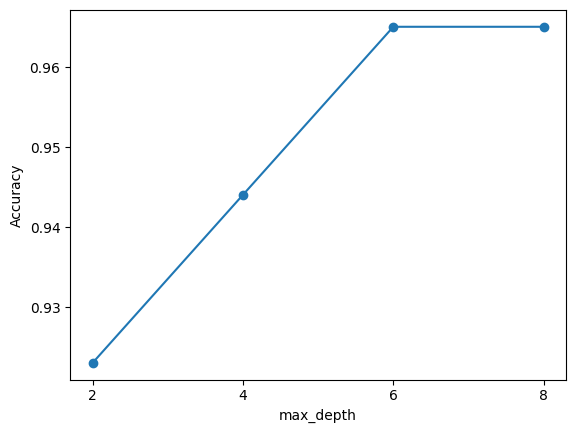

In [52]:
plt.scatter(range(len(model_accs)), model_accs)
plt.plot(range(len(model_accs)), model_accs)
plt.xticks(range(len(model_accs)), depth_values)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.show()

In [53]:
best_max_depth = depth_values[model_accs.index(max(model_accs))]
best_max_depth

6

Prelazimo na podešavanje drugog hiperparametra - mera nečistoće - _gini_ ili _entropy_?

In [54]:
criterions = ['gini', 'entropy']
model_accs = []

for criterion in criterions:
    model = DecisionTreeClassifier(max_depth=best_max_depth, criterion=criterion)
    model.fit(X_train, Y_train) 
    model_accs.append(model.score(X_test, Y_test))

model_accs

[0.965034965034965, 0.9440559440559441]

In [55]:
best_criterion = criterions[model_accs.index(max(model_accs))]
best_criterion

'gini'

Umesto podešavanja svakog hiperparametra pojedinačno, možemo isprobati sve kombinacije vrednosti hiperparametara. Može se desiti da je neka druga kombinacija koju nismo ispitali bolja.

In [56]:
model_accs = []

for depth in [2, 4, 6, 8]:
    accs_criterion = []

    for criterion in ['gini', 'entropy']:
        model = DecisionTreeClassifier(max_depth=depth, criterion=criterion)
        model.fit(X_train, Y_train) 
        accs_criterion.append(model.score(X_test, Y_test))
    
    model_accs.append(accs_criterion)

In [57]:
pd.DataFrame(model_accs, index=[2, 4, 6, 8], columns=['gini', 'entropy'])

,gini,entropy
2,0.923077,0.895105
4,0.944056,0.909091
6,0.972028,0.937063
8,0.965035,0.951049


Zašto ovo nije ispravan pristup? **Kompromitovali smo test skup - koristimo ga za izbor hiperparametara modela!**

### 8.2. Ispravan pristup - korišćenje validacionog skupa <span title="pickle" style="color: darkgreen "> ✔️ </span>

Umesto evaluacije modela za različite vrednosti hiperparametara na test skupu koristimo izdvojeni validacioni skup.

In [58]:
X_train, X_valid, Y_train, Y_valid = train_test_split(X_train, Y_train, train_size=0.8, stratify=Y_train, random_state=7)

In [59]:
X_train.shape[0]

340

In [60]:
X_valid.shape[0]

86

In [61]:
depth_values = [2, 4, 6, 8]
criterions = ['gini', 'entropy']
model_accs = []

for depth in depth_values:
    accs_criterion = []
    
    for criterion in criterions:
        model = DecisionTreeClassifier(max_depth=depth, criterion=criterion)
        model.fit(X_train, Y_train)
        accs_criterion.append(model.score(X_valid, Y_valid))
        
    model_accs.append(accs_criterion)    

In [62]:
pd.DataFrame(model_accs, index=depth_values, columns=criterions)

,gini,entropy
2,0.872093,0.872093
4,0.883721,0.895349
6,0.848837,0.872093
8,0.837209,0.895349


Vizuelizovati dobijene rezultate u vidu toplotne mape (eng. *heat map*).

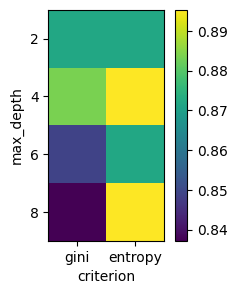

In [63]:
plt.figure(figsize=(3, 3))
plt.imshow(model_accs)
plt.xticks(range(len(criterions)), criterions)
plt.yticks(range(len(depth_values)), depth_values)
plt.xlabel('criterion')
plt.ylabel('max_depth')
plt.colorbar()
plt.show()

Nakon odabira najbolje kombinacije vrednosti hiperparametara, obučavamo i evaluiramo finalni model. 

In [64]:
final_model = DecisionTreeClassifier(max_depth=6, criterion='entropy')

In [65]:
X_train = pd.concat([X_train, X_valid])          #novi-stari trening skup (sa pripojenim validacionim skupom)
Y_train = pd.concat([Y_train, Y_valid])

In [66]:
X_train.shape[0]

426

In [67]:
final_model.fit(X_train, Y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [68]:
final_model.score(X_test, Y_test)

0.9370629370629371

### 8.3 Ispravan prisup - unakrsna validacija  <span title="pickle" style="color: darkgreen "> ✔️ </span>

Unakrsna validacija kao alternativa validacionom skupu - iscrpna pretraga kombinacija prosleđenih vrednosti hiperparametara za razlicite izbore validacionog skupa. 

<code>GridSearch</code> koristi princip unakrsne validacije (eng. *cross-validation*, *CV*). Pored iscrpne pretrage, postoji i <code>RandomSearchCV</code>, koja se korisiti kada imate veliki broj kombinacija. Detaljnije pogledati u dokumentaciji.

In [69]:
from sklearn.model_selection import GridSearchCV

U mapi čuvamo informaciju o imenima i vrednostima parametara koje želimo da ispitamo. Nazivi ključeva mape moraju da odgovaraju nazivima argumenata konstruktorske funkcije modela odgovarajućih hiperparametara.

In [70]:
params = {'max_depth': [2, 4, 6, 8],
          'criterion': ['gini', 'entropy']
         }

In [71]:
estimator = GridSearchCV(DecisionTreeClassifier(), param_grid=params, cv=3) # Po defaultu je cv=5

In [72]:
#estimator = GridSearchCV(DecisionTreeClassifier(), param_grid=params, cv=3, scoring = 'precision') 

In [73]:
estimator.fit(X_train, Y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [2, 4, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


Možemo pogledati koja je najbolja kombinacija vrednosti hiperparametara, kao i njemu odgovarajući skor modela:

In [74]:
estimator.best_params_

{'criterion': 'entropy', 'max_depth': 6}

In [75]:
estimator.best_score_

0.9248826291079811

Takođe možemo detaljnije pogledati i rezultate cross validacije.

In [76]:
estimator.cv_results_

{'mean_fit_time': array([0.00551049, 0.00701801, 0.00768058, 0.00795007, 0.0053614 ,
        0.00722488, 0.00727264, 0.00740131]),
 'std_fit_time': array([4.56354765e-04, 3.37028329e-04, 4.90662591e-04, 7.11323765e-04,
        1.24911516e-05, 1.14484675e-04, 3.08298875e-04, 4.01493883e-04]),
 'mean_score_time': array([0.00246501, 0.00236909, 0.00204945, 0.00213575, 0.00203633,
        0.00219035, 0.00199707, 0.00207957]),
 'std_score_time': array([1.35365215e-04, 2.04693362e-04, 4.22465344e-05, 8.36603513e-05,
        3.97351583e-05, 1.73519703e-04, 4.59982431e-06, 5.14311606e-05]),
 'param_criterion': masked_array(data=['gini', 'gini', 'gini', 'gini', 'entropy', 'entropy',
                    'entropy', 'entropy'],
              mask=[False, False, False, False, False, False, False, False],
        fill_value='?',
             dtype=object),
 'param_max_depth': masked_array(data=[2, 4, 6, 8, 2, 4, 6, 8],
              mask=[False, False, False, False, False, False, False, False],
    

Vizuelizovati dobijene rezultate u vidu toplotne mape (eng. *heat map*).

In [77]:
cv_test_scores = estimator.cv_results_['mean_test_score'].reshape(len(params['max_depth']), len(params['criterion']))
cv_test_scores

array([[0.92018779, 0.92018779],
       [0.92018779, 0.92018779],
       [0.9084507 , 0.92018779],
       [0.92488263, 0.91549296]])

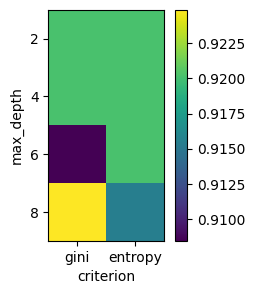

In [78]:
plt.figure(figsize=(3, 3))
plt.imshow(cv_test_scores)
plt.xticks(range(len(params['criterion'])), params['criterion'])
plt.yticks(range(len(params['max_depth'])), params['max_depth'])
plt.xlabel('criterion')
plt.ylabel('max_depth')
plt.colorbar()
plt.show()

Prikazati grafički strukturu najboljeg modela.

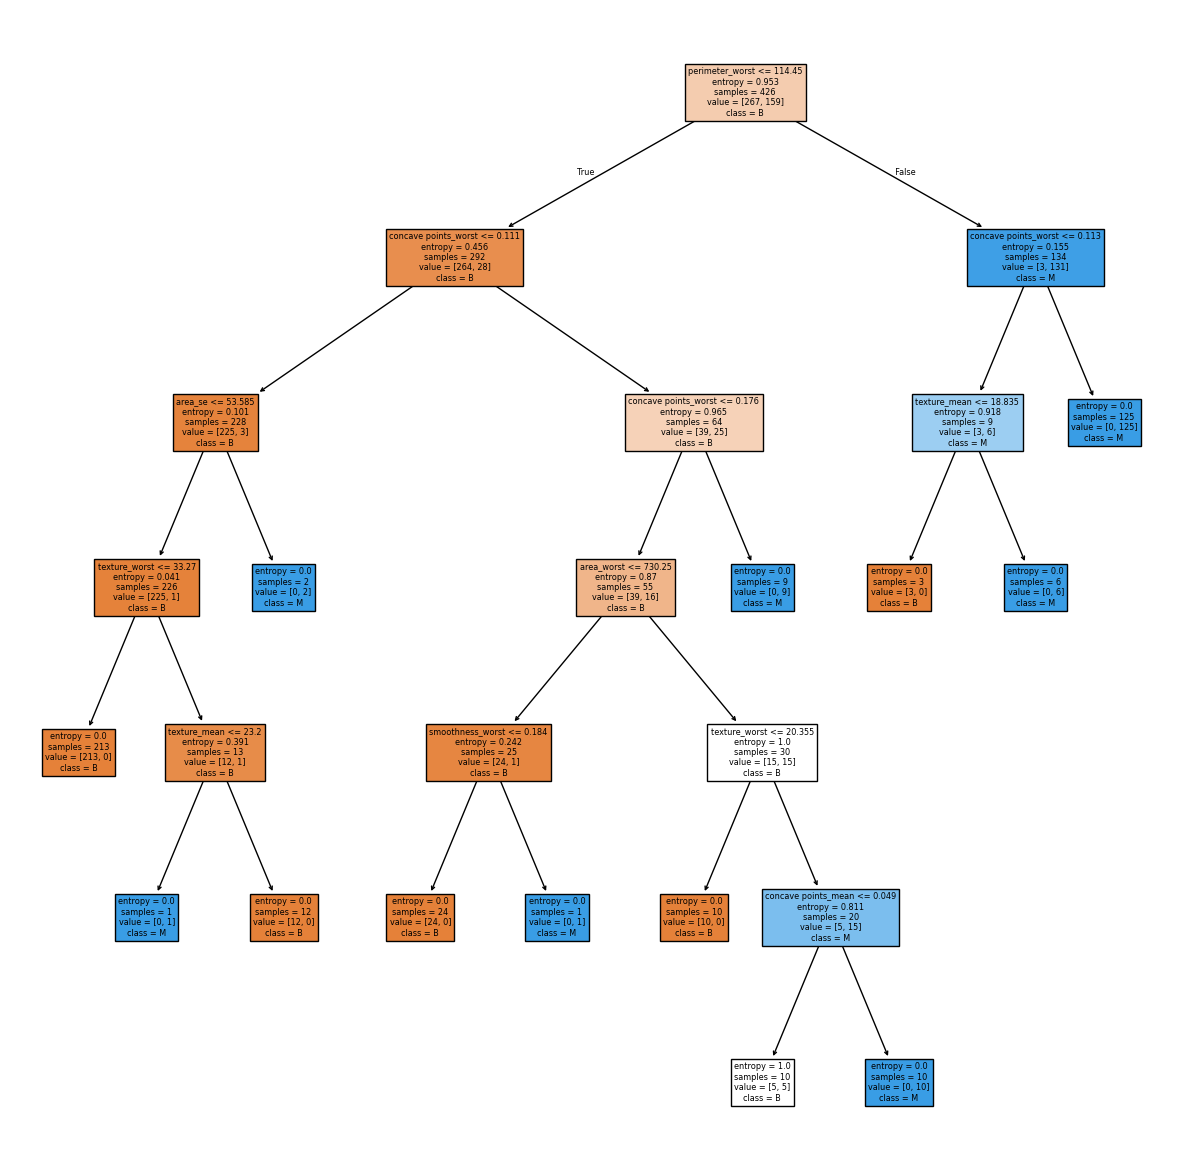

In [79]:
plt.figure(figsize=(15, 15))
_ = plot_tree(estimator.best_estimator_, feature_names=feature_names, class_names=['B', 'M'], filled=True)

Ispisati klasifikacioni izveštaj i matricu konfuzije najboljeg modela na treing i na test skupu.

In [80]:
Y_train_predicted = estimator.best_estimator_.predict(X_train)

In [81]:
confusion_matrix(Y_train, Y_train_predicted)

array([[267,   0],
       [  5, 154]])

In [82]:
print(classification_report(Y_train, Y_train_predicted))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       267
           1       1.00      0.97      0.98       159

    accuracy                           0.99       426
   macro avg       0.99      0.98      0.99       426
weighted avg       0.99      0.99      0.99       426



In [83]:
Y_test_predicted = estimator.best_estimator_.predict(X_test)

In [84]:
confusion_matrix(Y_test, Y_test_predicted)

array([[85,  5],
       [ 4, 49]])

In [85]:
print(classification_report(Y_test, Y_test_predicted))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95        90
           1       0.91      0.92      0.92        53

    accuracy                           0.94       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.94      0.94      0.94       143



_Pitanje 1_ : Koju meru <code>GridSearchCV</code> korisiti za odabir modela (šta je <code>score</code>)? 

_Pitanje 2_ : I dalje imamo više grešaka prvog reda... Kako bismo mogli da popravimo ovaj problem?

Na posletku, evaluirati najbolji model na test skupu.

In [86]:
estimator.best_estimator_.score(X_test, Y_test)            #ovo je konacna ocena modela

0.9370629370629371

### 9. Model slučajne šume

Slučajna šuma se sastoji od _m_ stabala treniranih na različitim podskupovima skupa za obučavanje.
* Jedno stablo se obučava na _slučajno odabranom_ podskupu skupa za treniranje.
* Mogu se korisititi i podskupovi skupa atributa.
* Hiperparametri : broj stabala (_m_) i veličina podskupa instanci i atributa.

Veće vrednosti za _m_ su bolje - manja šansa za preprilagođavanje, ali je računski zahtevnije.
Takođe, gubimo interpretabilnost modela.

In [87]:
from sklearn.ensemble import RandomForestClassifier

In [88]:
model_rf = RandomForestClassifier(n_estimators=2, random_state=42)

In [89]:
model_rf.fit(X_train, Y_train)

,n_estimators,2
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [90]:
model_rf.score(X_test, Y_test)

0.9020979020979021

Ispisati klasifikacioni izveštaj i matricu konfuzije na test skupu.

In [91]:
Y_test_predicted = model_rf.predict(X_test)

In [92]:
confusion_matrix(Y_test, Y_test_predicted)

array([[90,  0],
       [14, 39]])

In [93]:
print(classification_report(Y_test, Y_test_predicted))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93        90
           1       1.00      0.74      0.85        53

    accuracy                           0.90       143
   macro avg       0.93      0.87      0.89       143
weighted avg       0.92      0.90      0.90       143



Prikazati grafički strukturu oba stabla odlučivanja koja čine dati ansambl.

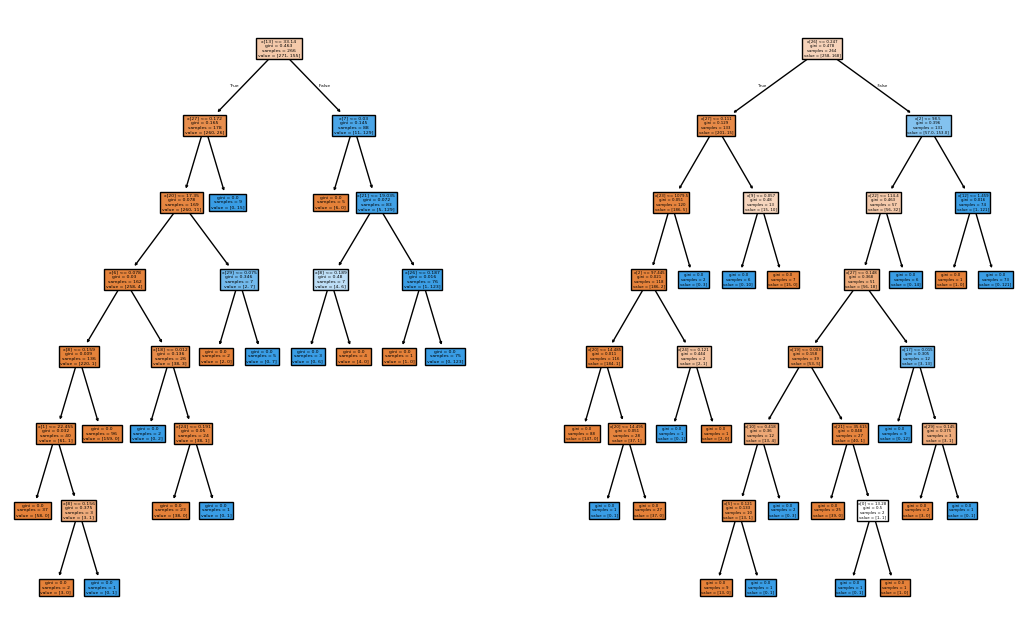

In [94]:
plt.figure(figsize=(13, 8))

for i in range(len(model_rf.estimators_)):
    plt.subplot(1, 2, i+1)
    plot_tree(model_rf.estimators_[i], filled=True)    

Detaljnije pogledajte kako se modeli ponašaju odvojeno, a kakav je kvalitet ansambla.

Pravimo slučajnu šumu koja se sastoji od 100 stabala odlučivanja

In [95]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [96]:
model_rf.fit(X_train, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [97]:
model_rf.score(X_test, Y_test)

0.965034965034965

Ispisati klasifikacioni izveštaj i matricu konfuzije na test skupu.

In [98]:
Y_test_predicted = model_rf.predict(X_test)

In [99]:
confusion_matrix(Y_test, Y_test_predicted)

array([[89,  1],
       [ 4, 49]])

In [100]:
print(classification_report(Y_test, Y_test_predicted))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        90
           1       0.98      0.92      0.95        53

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



### 10. Poređenje dobijenih modela

Napravili smo više modela, sada je pitanje koji od njih najbolje rešava problem klasifikacije. Naravno, ne možemo zaključiti samo na osnovu preciznosti modela. 
Za poređenje koristimo **ROC krivu**.

In [101]:
from sklearn.metrics import roc_curve

In [102]:
models = [model_dtc, estimator.best_estimator_, model_rf]
model_names = ['DecisionTree', 'GridSearchCV', 'RandomForest']

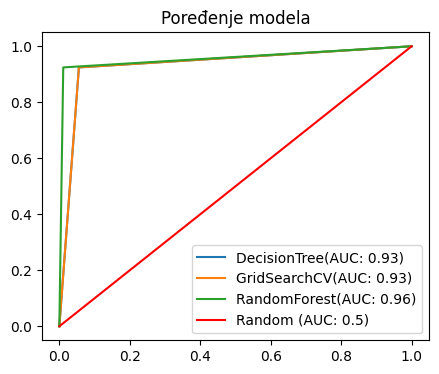

In [103]:
plt.figure(figsize=(5, 4))

for model, model_name in zip(models, model_names):
    Y_test_predicted = model.predict(X_test)
    FPR,TPR, _ = roc_curve(Y_test, Y_test_predicted)
    AUC_score = roc_auc_score(Y_test, Y_test_predicted)
    model_label = model_name + "(AUC: " + str(round(AUC_score, 2)) + ")"
    plt.plot(FPR, TPR, label=model_label)

plt.plot([0, 1], [0, 1], label='Random (AUC: 0.5)', color='red')
plt.title("Poređenje modela")
plt.legend()
plt.show()

Biramo model sa najvećom AUC vrednošću - **Random Forest**.

### 11. Čuvanje i ponovno korišćenje modela <span title="pickle" style="color: darkgreen ">🥒</span>

In [104]:
import pickle

In [105]:
with open('RandomTreeModel.pkl', 'wb') as file:  
    pickle.dump(model_dtc, file)

In [106]:
with open('RandomTreeModel.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

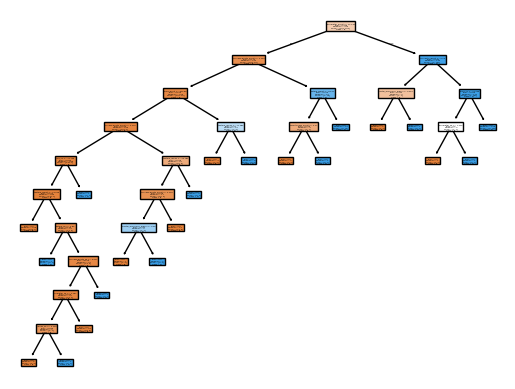

In [107]:
_ = plot_tree(loaded_model, feature_names=feature_names, class_names=['B', 'M'], filled=True)

U slučaju korišćenja scikit-learn biblioteke, bolje je koristiti **joblib**, koja je efikasnija za objekte koji interno čuvaju velike numpy nizove (samo ako imate velike modele).

In [108]:
import joblib

In [109]:
with open('RandomTreeModel.pkl', 'wb') as file:  
    joblib.dump(model_dtc, file)

In [110]:
with open('RandomTreeModel.pkl', 'rb') as file:
    loaded_model = joblib.load(file)   

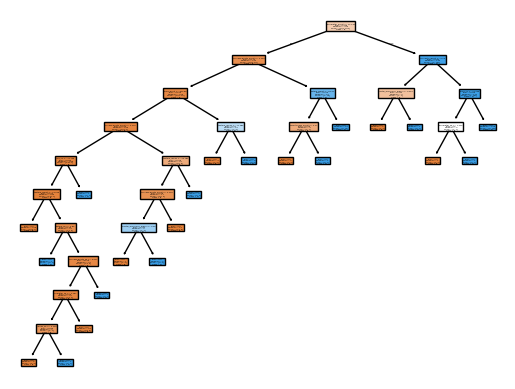

In [111]:
_ = plot_tree(loaded_model, feature_names=feature_names, class_names=['B', 'M'], filled=True)

### Za vežbu:
* Pokušajte da poboljšate model finijim podešavanjem parametara
* Na početku smo naglasili da radimo sa blago nebalansiranim klasama, da li bi postavljanje parametra <code>class_weight</code> na "blanced" tokom treniranja poboljšalo model?